In [1]:
%matplotlib widget

In [2]:
# imports
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

In [3]:
# function calculate the norm for every row vector in R2, according to p
def lp_norm(points, p=2):
    points = np.asarray(points) # make shure that points is numpy array
    if np.isinf(p): # if p is infinity the formula for norm is different
        return np.max(np.abs(points), axis=1)
    return np.sum(np.abs(points)**p, axis=1)**(1.0/p)

In [4]:
vX = np.arange(-2, 2.02, 0.02).round(2) # defining of x coordinate range
vY = np.arange(-2, 2.02, 0.02).round(2) # defining of y coordinate range
mXX, mYY = np.meshgrid(vX, vY)
X = np.column_stack([mXX.ravel(), mYY.ravel()]) # creating all relevant coordinates grid

In [5]:
p0 = 2.0 # initialization of p parameter
mask = lp_norm(X, p0) <= 1 # wether value of norm below or equal to zero

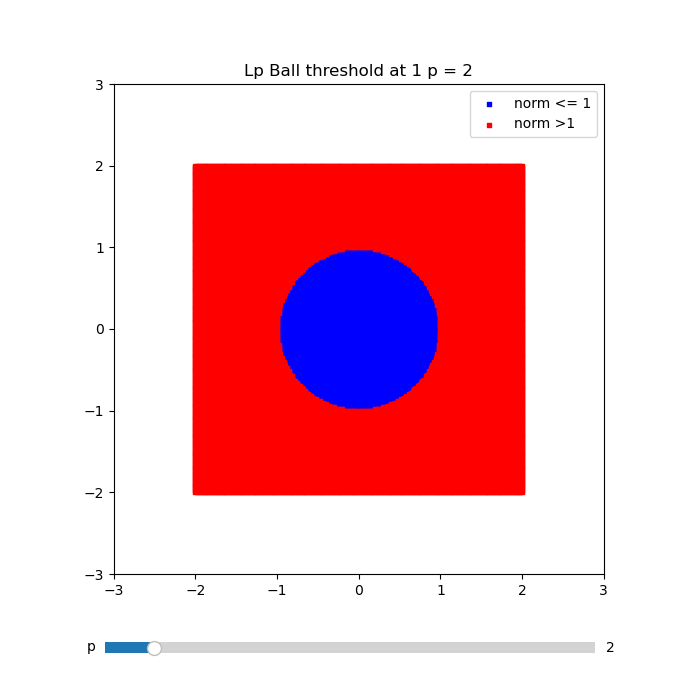

In [6]:
fig, ax = plt.subplots(figsize=(7,7))
plt.subplots_adjust(bottom=0.18) # place for slider, not to overlap with plot
ax.set_aspect('equal', adjustable='box') # axises are equal, because of the set limits, the box is ajustable
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)

sc_in = ax.scatter(X[mask, 0], X[mask, 1], marker='s', s=6, label='norm <= 1', c='blue')
sc_out = ax.scatter(X[~mask, 0], X[~mask, 1], marker='s', s=6, label='norm >1', c='red')

ax.legend(loc='upper right')
title = ax.set_title(f"Lp Ball threshold at 1 p = {p0:.0f}")
ax_p = plt.axes([0.15, 0.06, 0.7, 0.03]) # [left, bottom, width, height]

p_slider = Slider(ax=ax_p, label='p', valmin=1, valmax=11, valinit=p0, valstep=1)


def update_figure(_):
    slider_val = float(p_slider.val)
    if slider_val == 11.0:
        p0 = np.inf
        title_val = '∞'
    else:
        p0 = slider_val
        title_val = str(p0)
        
    mask = lp_norm(X, p0) <= 1.0
    sc_in.set_offsets(X[mask])
    sc_out.set_offsets(X[~mask])
    title.set_text(f"Lp Ball threshold at 1 p = {title_val}")
    p_slider.valtext.set_text(title_val)
    fig.canvas.draw_idle()

p_slider.on_changed(update_figure)
plt.show()




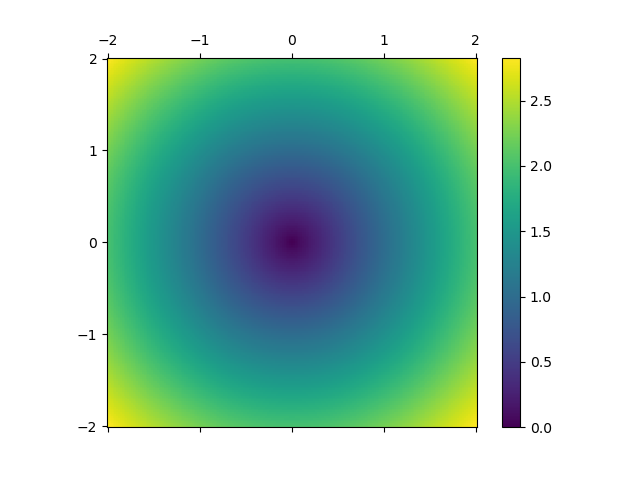

In [7]:
vX = np.arange(-2, 2.02, 0.02)
XX, YY = np.meshgrid(vX, vX)
mPoints = np.column_stack([XX.ravel(), YY.ravel()])
vNorm = lp_norm(mPoints, p=2)
mNorm = vNorm.reshape(-1, len(vX))

step = vX[1] - vX[0]
half = step / 2
extent = (vX[0] - half, vX[-1] + half, vX[0] - half, vX[-1] + half)

fig, ax = plt.subplots()
img = ax.matshow(mNorm, extent=extent, origin ='lower')
fig.colorbar(img, ax=ax)
plt.show()

in the next session i wanto write a script which takes  parameter a and b and builds line y = a*x + b

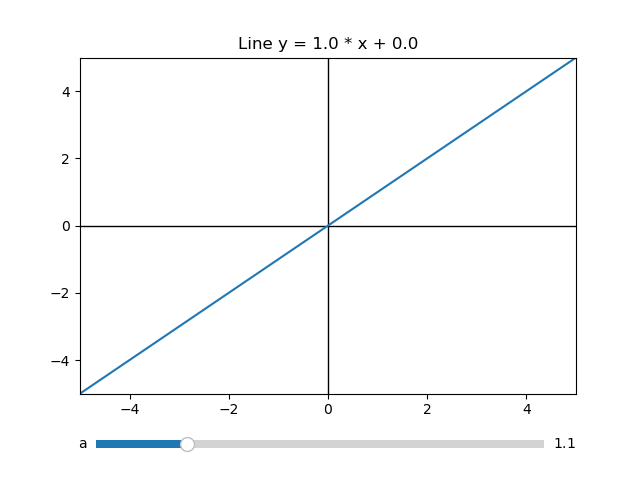

In [8]:
a_init = 1.0
b_init = 0.0

def line_f(vX, a, b):
    return np.asarray(vX * a + b)

vX = np.linspace(-5, 5, 100)
y = line_f(vX, a_init, b_init)
fig, ax = plt.subplots()

ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
plt.subplots_adjust(bottom=0.18) # place for slider, not to overlap with plot

line,  = ax.plot(vX, y)
title = ax.set_title(f"Line y = {a_init:.1f} * x + {b_init:.1f}")

# define the axis for slider
ax_a = fig.add_axes([0.15, 0.06, 0.7, 0.03])
a_slider = Slider(ax=ax_a, label='a', valmin=0.1, valmax=5, valinit=a_init, valstep=0.5)

def update_figure(_):
    a = float(a_slider.val)
    y=line_f(vX, a, b_init)
    line.set_ydata(y)
    title.set_text(f"Line y = {a:.1f} * x + {b_init:.1f}")
    fig.canvas.draw_idle()

a_slider.on_changed(update_figure)
plt.show()


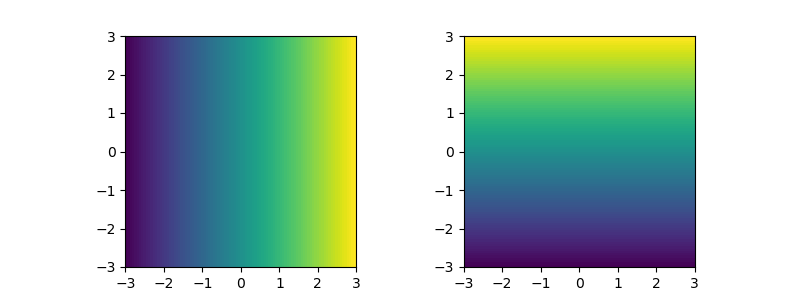

In [9]:
# training of matshow

lowerBoundary = -3
upperBoundary = 3
pointsResolution = 100
vG = np.linspace(lowerBoundary, upperBoundary, pointsResolution)
mXX, mYY = np.meshgrid(vG, vG)
tuXY = (mXX, mYY)
fig, ax = plt.subplots(1, 2, figsize=(8,3))
for index, ax_holder in enumerate(ax):
    ax_holder.matshow(tuXY[index], extent=(vG[0], vG[-1], vG[0], vG[-1]), origin='lower')
    ax_holder.xaxis.set_ticks_position('bottom')
    #ax_holder.xaxis.set_label_position('bottom')

plt.show()



1. I want to add the same figure, where i can choose the the specific values for p: 1, 2, inf
2. Create the repo backing (add to ml-cource)


In [18]:
# training np.stack
vX = np.linspace(-3, 3, 7)
mX1, mX2 = np.meshgrid(vX, vX)
mXY = np.stack([mX1.flatten(), mX2.flatten()], axis=1)
mXY.shape

(49, 2)

In [8]:
from ipywidgets import FloatSlider, interact
def test(p):
    print("p= ", p)
slider = FloatSlider(min=12.0, max=18.0, value=14.0, step=1.0, continious_update=False)
interact(test, p=slider)

interactive(children=(FloatSlider(value=14.0, description='p', max=18.0, min=12.0, step=1.0), Output()), _dom_…

<function __main__.test(p)>